# PHYS-467 Machine Learning for Physisicst 

Gradient Descent

***Exercise 5.1: Vanilla gradient descent***

1.   Load the MNIST dataset and pre-process it;
2.   Write a function that performs gradient descent with $l_2$ regularized binary cross-entropy;
3.   Plot the train and validation loss;
4.   Compute the test error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

*Exercise 5.1 - 1: load MNIST and pre-process it* 

In [2]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data() # load the MNIST dataset through keras

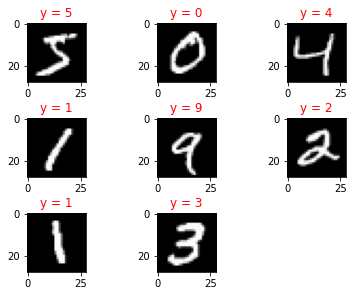

In [3]:
# display the first 8 digits

for i in range(8):  
  plt.subplot(3, 3,  i + 1) # create the plot container
  plt.imshow(X_train[i], cmap=plt.get_cmap('gray')) # plot the image
  plt.tight_layout(pad = 0.3) # add space between subplots
  plt.title("y = " + str(y_train[i]), color = 'red') # print labels as a title
plt.show() # show the plot

In [4]:
# get info on the dataset

print("X_train shape = ", np.shape(X_train), "----------------", "y_train shape = ", np.shape(y_train))
print("max pixel value in X_train = ", X_train.max(), "---------------", "min pixel value in X_train = ", X_train.min())
print("")
print("X_test shape = ", np.shape(X_test), "----------------", "y_test shape = ", np.shape(y_test))
print("max pixel value in X_test = ", X_test.max(), "---------------", "min pixel value in X_test = ", X_test.min())

X_train shape =  (60000, 28, 28) ---------------- y_train shape =  (60000,)
max pixel value in X_train =  255 --------------- min pixel value in X_train =  0

X_test shape =  (10000, 28, 28) ---------------- y_test shape =  (10000,)
max pixel value in X_test =  255 --------------- min pixel value in X_test =  0


In [5]:
# split the dataset in train/test/validation set

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

In [6]:
print("X_train shape = ", np.shape(X_train), "--------------", "y_train shape = ", np.shape(y_train))
print("")
print("X_val shape = ", np.shape(X_val), "----------------", "y_val shape = ", np.shape(y_val))
print("")
print("X_test shape = ", np.shape(X_test), "---------------", "y_test shape = ", np.shape(y_test))


X_train shape =  (48000, 28, 28) -------------- y_train shape =  (48000,)

X_val shape =  (12000, 28, 28) ---------------- y_val shape =  (12000,)

X_test shape =  (10000, 28, 28) --------------- y_test shape =  (10000,)


In [7]:
# pre-process the dataset

def dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type = "even-odd_digits"):
  """
  This function pre-process the train, test and validation datasets.
    Input:   (X_train, y_train), (X_test, y_test), (X_val, y_val) = train/test/validation set
             relabelling_type =  partition type of the MNIST dataset. Supported types: even/odd digits, greater/smaller than 5 digits.
    Output:  pre-processed dataset
  """
  
  # rescale the inputs in 0-1
  X_train = X_train/255
  X_val = X_val/255
  X_test = X_test/255

  # put images in a vector rather than a matrix
  X_train = np.reshape(X_train, (len(X_train), 28*28))
  X_val = np.reshape(X_val, (len(X_val), 28*28))
  X_test = np.reshape(X_test, (len(X_test), 28*28))

  # rescale the data in order to have pre-activations of order 1
  X_train = X_train/np.sqrt(784)
  X_val = X_val/np.sqrt(784)
  X_test = X_test/np.sqrt(784)

  # relabel MNIST to be suitable for a binary classifier  
  if relabelling_type == "greater-smaller-than-five_digits":
    y_train[y_train <= 5.] = 0
    y_train[y_train > 5.] = 1
    y_val[y_val <= 5.] = 0
    y_val[y_val > 5.] = 1
    y_test[y_test <= 5.] = 0
    y_test[y_test > 5.] = 1
  elif relabelling_type == "even-odd_digits":
    y_train[y_train%2 == 0] = 0
    y_train[y_train%2 == 1] = 1
    y_val[y_val%2 == 0] = 0
    y_val[y_val%2 == 1] = 1
    y_test[y_test%2 == 0] = 0
    y_test[y_test%2 == 1] = 1
    
  return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = dataset_preprocessing(X_train, y_train, X_val, y_val, X_test, y_test, relabelling_type="even-odd_digits")

In [8]:
# look how the dataset has been changed

print("X_train shape = ", np.shape(X_train), "----------------", "y_train shape = ", np.shape(y_train))
print("max pixel value in X_train = ", X_train.max(), "---------------", "min pixel value in X_train = ", X_train.min())
print("")
print("X_val shape = ", np.shape(X_val), "----------------", "y_val shape = ", np.shape(y_val))
print("max pixel value in X_val = ", X_val.max(), "---------------", "min pixel value in X_val = ", X_val.min())
print("")
print("X_test shape = ", np.shape(X_test), "----------------", "y_test shape = ", np.shape(y_test))
print("max pixel value in X_test = ", X_test.max(), "---------------", "min pixel value in X_test = ", X_test.min())

X_train shape =  (48000, 784) ---------------- y_train shape =  (48000,)
max pixel value in X_train =  0.03571428571428571 --------------- min pixel value in X_train =  0.0

X_val shape =  (12000, 784) ---------------- y_val shape =  (12000,)
max pixel value in X_val =  0.03571428571428571 --------------- min pixel value in X_val =  0.0

X_test shape =  (10000, 784) ---------------- y_test shape =  (10000,)
max pixel value in X_test =  0.03571428571428571 --------------- min pixel value in X_test =  0.0


*Exercise 5.1 - 2: write gradient descent algorithm*

In [9]:
import time
import pandas as pd
from sklearn.metrics import mean_squared_error

In [10]:
# write down the gradient descent algorithm

def sigmoid(x):
  """
  This function computes the sigmoid of the pre-activations.
  Input:  x = variable of interest.
  Output: sig = sigmoid.  
  """

  sig = np.exp(x)/(1+np.exp(x)) #sigmoid 
  return sig

def binary_cross_entropy_loss(y, y_pred):
  """
  This function computes the binary cross entropy loss given the dataset and the actual estimator.
  Input: y = actual label;
         y_pred = predicted label.
  Output: bc = binary cross-entropy loss
  """
    
  bc = -(y*np.log(y_pred)+(1-y)*np.log(1-y_pred)).mean() # computes the binary cross-entropy loss
  return bc

def gradient(X, y, y_pred):
  """
  This function computes the gradient of the binary-cross entropy loss with respect to the weights.
  Input: (X, y) = dataset;
          y_pred = predicted labels.
  Output: gradient
  """
  grad = - X * (y - y_pred) # gradient of the binary cross-entropy loss
  return grad
    
def run_gd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change):
  """
  This function run the gradient descent algorithm and save results on file.
  Input: (X, y), (X_val, y_val) = train and validation set;
         lamb = regularization strength;
         eta = learning rate;
         epochs = maximum number of iterations;
         tol = tolerance;
         frequency = frequency at which the results are printed on the screen;
         verbose = flag to decide whether to print or not information about the algorithm convergence;
         n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs
  Output: W = estimated weights 
  """  

  res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
  W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
  counter_train = 0
  train_loss_prec = 100
  y_pred = sigmoid(X @ W) # compute the predicted labels at epoch = 0
  
  for epoch in range(epochs): # loop over epochs    
    # compute the gradient and update the weights    
    grad = 0. # set initially the gradient to zero
    for mu in range(len(y)): # loop over the data  
      grad += gradient(X[mu], y[mu], y_pred[mu]) #cumulate the gradient over the inputs
    grad += lamb * W # add the contribution of the regularization
    W -= eta * grad # update the weights
    norm_grad = np.linalg.norm(grad)

    # compute the metrics for the new estimator
    y_pred = sigmoid(X @ W) # compute the predicted labels
    train_loss = binary_cross_entropy_loss(y, y_pred)
    y_pred_val = sigmoid(X_val @ W) # compute the predicted labels
    val_loss = binary_cross_entropy_loss(y_val, y_pred_val)

    # save the results
    res["epoch"].append(epoch) # populate the dictionary
    res["train_loss"].append(train_loss)
    res["val_loss"].append(val_loss)
    res["gradient_norm"].append(norm_grad)

    # check whether the algorithm is converging    
    if epoch % frequency == 0 and verbose == 1: # display results
      print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
    if np.abs(train_loss_prec - train_loss) <= tol: # check whether the loss is not moving
      counter_train += 1 # update the counter
      if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
        break # if yes exit the loop
    else:
      counter_train = 0
   
    train_loss_prec = train_loss # assign to the previous training loss its actual value
    
  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv("./training_gd.csv", mode = 'w', index = False) # write the csv file
  return W  

In [11]:
# Run GD

n = 1000
X_train_slice = X_train[:n]
y_train_slice = y_train[:n]
eta = 0.1
epochs = 5000
lamb = 1e-5
tol = 1e-5
frequency = 1
verbose = 1
n_iter_no_change = 5

start = time.time() # starting time
W_gd = run_gd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs



epoch:  0 train loss =  0.7099604968429465 val loss =  0.7105811699994583 gradient_norm =  26.97328771357874
epoch:  1 train loss =  0.7032894280970353 val loss =  0.7045735519601382 gradient_norm =  26.03605098127856
epoch:  2 train loss =  0.6970123935524984 val loss =  0.6988992196215468 gradient_norm =  25.232773562558428
epoch:  3 train loss =  0.6910659559194751 val loss =  0.6935020733406553 gradient_norm =  24.540324401581028
epoch:  4 train loss =  0.6853999975472382 val loss =  0.6883384280902602 gradient_norm =  23.938858272529636
epoch:  5 train loss =  0.6799748878552926 val loss =  0.6833742773399323 gradient_norm =  23.411645295346407
epoch:  6 train loss =  0.6747592240115072 val loss =  0.6785831263937739 gradient_norm =  22.944784056038404
epoch:  7 train loss =  0.6697280417138045 val loss =  0.6739442893796437 gradient_norm =  22.526859065975927
epoch:  8 train loss =  0.664861406012869 val loss =  0.6694415585572038 gradient_norm =  22.148585794771122
epoch:  9 tra

*Exercise 5.1 - 3: plot train and validation loss* 

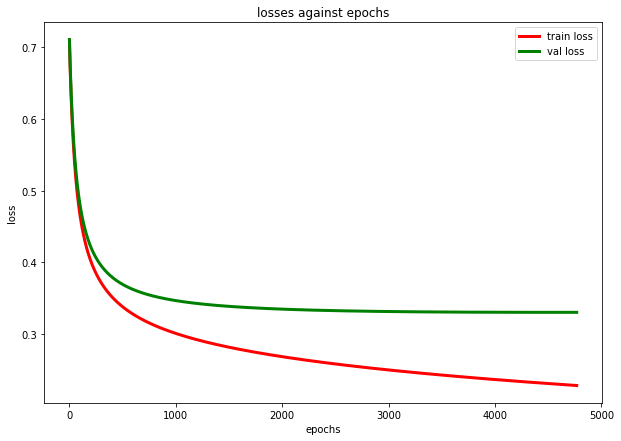

In [12]:
# plot the results

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./training_gd.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='train loss') # plot the results with matplotlib through pandas


res.plot(x='epoch',
         y='val_loss',
         color = 'green',
         lw = 3,
         ax=ax,
         label='val loss')

ax.set_title("losses against epochs") # set the plot title
ax.set_ylabel("loss") # set the name of the y axis
ax.set_xlabel("epochs") # set the name of the x axis
#ax.set_xlim(0.3,10**(-10)) # set the range of the x axis
ax.legend(loc = 'upper right') # specify the position of the legend

*Exercise 5.1 - 4: compute the test error* 

In [13]:
# compute the test error for the gd estimators

y_test_pred = sigmoid(X_test@W_gd) # compute the prediction
test_error_gd = mean_squared_error(y_test, y_test_pred) # compute the test error 
print("The test error associated to the estimator computed by gd is: ", test_error_gd) # print it

The test error associated to the estimator computed by gd is:  0.09702722613111026


***Exercise 5.2: Vanilla gradient descent plus early stopping***

1.   Write gradient descent including early stopping;
2.   Plot the train loss and the validation loss;
3.   Compare the test error associated to gd and the one associtated to gd + early stopping

*Exercise 5.2 -- 1: write gd including early-stopping*

In [14]:
# Write GD plus early stopping

def run_gradient_descent_w_early_stopping(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, patience):
  """
  This function run the gradient descent algorithm and save results on file.
  Input: (X, y), (X_val, y_val) = train and validation set;
         lamb = regularization strength;
         eta = learning rate;
         epochs = maximum number of iterations;
         tol = tolerance;
         frequency = frequency at which the results are printed on the screen;
         verbose = flag to decide whether to print or not information about the algorithm convergence;
         patience = number of iterations counted from the point where the validation loss has started to increase.
  Output: W = estimated weights 
  """  

  res = {"epoch": [], "train_loss": [], "val_loss": []} # initialize an empty disctionary where to save results  
  W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
  counter_train = 0 # initialize a counter
  counter_val = 0 # initialize a counter
  train_loss_prec = 100. # initialize a starting value for the training loss
  val_loss_prec = 100. # initialize a starting value for the validation loss
  y_pred = sigmoid(X @ W) # compute the predicted labels for epoch = 0 

  for epoch in range(epochs): # loop over epochs
    # compute the gradient and update the weights    
    grad = 0. # set initially the gradient to zero
    for mu in range(len(y)): # loop over the data  
      grad += gradient(X[mu], y[mu], y_pred[mu]) #cumulate the gradient over the inputs
    grad += lamb * W # add the contribution of the regularization
    W -= eta * grad # update the weights
    norm_grad = np.linalg.norm(grad)

    # compute the metrics for the new estimator
    y_pred = sigmoid(X @ W) # compute the predicted labels at the end of each epoch
    train_loss = binary_cross_entropy_loss(y, y_pred)
    y_pred_val = sigmoid(X_val @ W) # compute the predicted labels
    val_loss = binary_cross_entropy_loss(y_val, y_pred_val)

    # save the results
    res["epoch"].append(epoch) # populate the disctionary
    res["train_loss"].append(train_loss)
    res["val_loss"].append(val_loss)

    # check whether the algorithm is converging
    grad_max =  np.amax(grad) # take the greater component of the gradient
    # display results
    if epoch % frequency == 0 and verbose == 1:
      print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
    if np.abs(train_loss_prec - train_loss) <= tol: # check whether the loss is not moving
      counter_train += 1 # update the counter
      if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
        break # if yes exit the loop
    else:
      counter_train = 0
    train_loss_prec = train_loss # assign to the previous training loss its actual value

    if val_loss >= val_loss_prec: #check whether the validation loss is increasing
      counter_val += 1 # if yes update the counter     
      if counter_val >= patience: # if the counter is greater than patience exit the loop       
        break 
    else:
      counter_val = 0     
    val_loss_prec = val_loss  # substitute the previous value of the validation loss with the current one
    
  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv("./training_es.csv", mode = 'w', index = False) # write the csv file
  return W

In [15]:
# Run GD plus early stopping

patience = 5

start = time.time() # starting time
W_gd_w_es = run_gradient_descent_w_early_stopping(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, patience)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

epoch:  0 train loss =  0.7234904287079296 val loss =  0.7278738517687448 gradient_norm =  30.52328607849858
epoch:  1 train loss =  0.7153508099691119 val loss =  0.7202355997848351 gradient_norm =  28.888978451298996
epoch:  2 train loss =  0.7079536154312815 val loss =  0.7132936772457539 gradient_norm =  27.502025861947004
epoch:  3 train loss =  0.701157365805834 val loss =  0.7069129242920297 gradient_norm =  26.327393923026325
epoch:  4 train loss =  0.6948504782815651 val loss =  0.7009871398435126 gradient_norm =  25.332347040359526
epoch:  5 train loss =  0.6889452071128167 val loss =  0.6954331555323706 gradient_norm =  24.48730488388147
epoch:  6 train loss =  0.6833726594717764 val loss =  0.690185970104749 gradient_norm =  23.766256132149252
epoch:  7 train loss =  0.6780787644404882 val loss =  0.6851948218357581 gradient_norm =  23.146834820987465
epoch:  8 train loss =  0.6730210528205338 val loss =  0.6804200574302398 gradient_norm =  22.610161981094993
epoch:  9 trai

*Exercise 5.2 -- 2: plot train and validation losses*

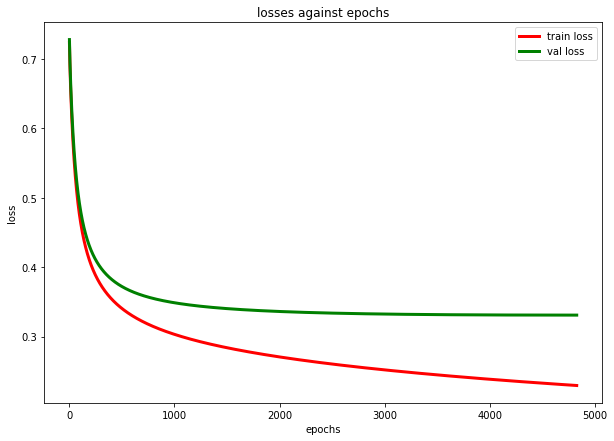

In [16]:
# plot the results

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./training_es.csv") # read the content of the *.csv file

res.plot(x='epoch',
         y='train_loss',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='train loss') # plot the results with matplotlib through pandas


res.plot(x='epoch',
         y='val_loss',
         color = 'green',
         lw = 3,
         ax=ax,
         label='val loss')

ax.set_title("losses against epochs") # set the plot title
ax.set_ylabel("loss") # set the name of the y axis
ax.set_xlabel("epochs") # set the name of the x axis
#ax.set_xlim(0.3,10**(-10)) # set the range of the x axis
ax.legend(loc = 'upper right') # specify the position of the legend

*Exercise 5.2 -- 3: compute the test error and compare it with the one obtained without early-stopping*

In [17]:
# compare GD test error with GD + early stopping 

y_test_pred = sigmoid(X_test@W_gd) # compute the prediction
test_error_gd = mean_squared_error(y_test, y_test_pred) # compute the test error for GD
print("The test error associated to the estimator computed by gd is: ", test_error_gd) # print it

y_test_pred = sigmoid(X_test@W_gd_w_es) # compute the prediction 
test_error_gd_w_es = mean_squared_error(y_test, y_test_pred) # compute the test error for GD plus early stopping
print("The test error associated to the estimator computed by gd plus early stopping is: ", test_error_gd_w_es) # print it

The test error associated to the estimator computed by gd is:  0.09702722613111026
The test error associated to the estimator computed by gd plus early stopping is:  0.0972081045511314


***Exercise 5.3: Stochastic gradient descent***

1.   Write a function that performs stochastic gradient descent algoritm (batch size = 1) with $l_2$ regularized binary cross-entropy;
2.   Plot the training loss versus epochs for both gradient descent and stochastic gradient descent;
3.   Compute the test error.

*Exercise 5.3 -- 1: sgd*

In [18]:
# Write SGD

def run_sgd(X, y, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change):
  """
  This function run the stochastic gradient descent algorithm and save results on file.
  Input: (X, y), (X_val, y_val) = train and validation set;
         lamb = regularization strength;
         eta = learning rate;
         epochs = maximum number of iterations;
         tol = tolerance;
         frequency = frequency at which the results are printed on the screen;
         verbose = flag to decide whether to print or not information about the algorithm convergence;
         n_iter_no_change = number of iterations we want to wait when the train loss starts not changing more than tol accross the epochs
  Output: W = estimated weights 
  """  

  res = {"epoch": [], "train_loss": [], "val_loss": [], "gradient_norm": []} # initialize an empty disctionary where to save results  
  W = np.random.normal(0., 1., size = (len(X[0]))) # initialize the weights
  counter_train = 0
  train_loss_prec = 100
  
  for epoch in range(epochs): # loop over epochs    
    # compute the gradient and update the weights
    grad = 0. # set initially the gradient to zero
    for mu in np.random.permutation(range(len(y))): # loop over the data 
      y_pred = sigmoid(X @ W) # compute the predicted label   
      grad = gradient(X[mu], y[mu], y_pred[mu]) # calculate the gradient just for current example mu
      grad += lamb * W # add the contribution of the regularization
      W -= eta * grad # update the weights
      norm_grad = np.linalg.norm(grad)

    # compute the metrics for the new estimator
    y_pred = sigmoid(X @ W) #compute the predicted labels at the end of the epoch
    train_loss = binary_cross_entropy_loss(y, y_pred)
    y_pred_val = sigmoid(X_val @ W) # compute the predicted labels
    val_loss = binary_cross_entropy_loss(y_val, y_pred_val)

    # save the results
    res["epoch"].append(epoch) # populate the disctionary
    res["train_loss"].append(train_loss)
    res["val_loss"].append(val_loss)
    res["gradient_norm"].append(norm_grad)

    # check whether the algorithm is converging
    grad_max =  np.amax(grad) # take the greater component of the gradient
    # display results
    if epoch % frequency == 0 and verbose == 1:
      print("epoch: ", epoch, "train loss = ", train_loss, "val loss = ", val_loss, "gradient_norm = ", norm_grad)
    if np.abs(train_loss_prec - train_loss) <= tol: # check whether the loss is not moving
      print("HERE")
      counter_train += 1 # update the counter
      if counter_train >= n_iter_no_change: # check whether the loss has not changed in a certain time interval 
        break # if yes exit the loop
    else:
      counter_train = 0
   
    train_loss_prec = train_loss # assign to the previous training loss its actual value
    
  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe
  res.to_csv("./training_sgd.csv", mode = 'w', index = False) # write the csv file
  return W

In [19]:
# Run SGD 
start = time.time() # starting time
W_sgd = run_sgd(X_train_slice, y_train_slice, X_val, y_val, lamb, eta, epochs, tol, frequency, verbose, n_iter_no_change)
print("total computational time in seconds = ", time.time() - start) # print how much the algorithm took to run for a number of epochs = epochs

epoch:  0 train loss =  0.6792918329259292 val loss =  0.6799706465219788 gradient_norm =  0.25415917928339177
epoch:  1 train loss =  0.6747060126386606 val loss =  0.6756194999365974 gradient_norm =  0.1564353435759356
epoch:  2 train loss =  0.6702252820711372 val loss =  0.6713710918735479 gradient_norm =  0.17351912186681373
epoch:  3 train loss =  0.665841544377772 val loss =  0.6672148871891471 gradient_norm =  0.11543865159488616
epoch:  4 train loss =  0.6615587300130973 val loss =  0.6631593374788991 gradient_norm =  0.15004106264182537
epoch:  5 train loss =  0.6573640833336488 val loss =  0.6591852517421132 gradient_norm =  0.1874250021958683
epoch:  6 train loss =  0.6532594798500209 val loss =  0.6552978360438895 gradient_norm =  0.13169802345009507
epoch:  7 train loss =  0.649241098058732 val loss =  0.6514916117825303 gradient_norm =  0.18613751500462386
epoch:  8 train loss =  0.6453073522799393 val loss =  0.647765821447052 gradient_norm =  0.11078178761666531
epoch:

*Exercise 5.3 -- 2: plot train losses for both gd and sgd*

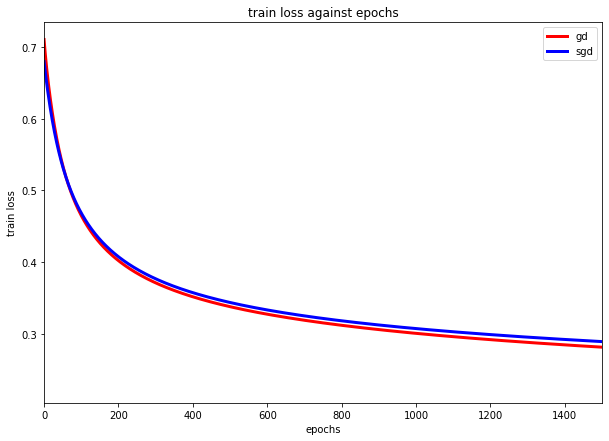

In [20]:
# plot the train loss for both gd and sgd

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res_gd = pd.read_csv("./training_gd.csv") # read the content of the *.csv file
res_sgd = pd.read_csv("./training_sgd.csv") # read the content of the *.csv file

res_gd.plot(x='epoch',
         y='train_loss',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='gd') # plot the results with matplotlib through pandas


res_sgd.plot(x='epoch',
         y='train_loss',
         color = 'blue',
         lw = 3,
         ax=ax,
         label='sgd')

ax.set_title("train loss against epochs") # set the plot title
ax.set_ylabel("train loss") # set the name of the y axis
ax.set_xlabel("epochs") # set the name of the x axis
ax.set_xlim(0.0,1500) # set the range of the x axis
ax.legend(loc = 'upper right') # specify the position of the legend

*Exercise 5.3 -- 3: compute sgd test error*

In [21]:
# compute the test error for sgd

y_test_pred = sigmoid(X_test@W_gd) # compute the prediction
test_error_gd = mean_squared_error(y_test, y_test_pred) # compute the test error for GD
print("The test error associated to the estimator computed by gd is: ", test_error_gd) # print it

y_test_pred = sigmoid(X_test@W_sgd) # compute the prediction
test_error_sgd = mean_squared_error(y_test, y_test_pred) # compute the test error for SGD
print("The test error associated to the estimator computed by sgd is: ", test_error_sgd) # print it

The test error associated to the estimator computed by gd is:  0.09702722613111026
The test error associated to the estimator computed by sgd is:  0.09832620509468204
